# Stage 2: Feature Engineering & Exploratory Visualizations

**Objective:** Derive domain-specific features (temperature deltas, mechanical power) to provide the model with stronger predictive signals. Validate the effectiveness of these new features through correlation analysis and distribution plots.

In [1]:
import numpy as np
import pandas as pd


# Load cleaned data
df = pd.read_csv('../data/processed/cleaned_data.csv')

# Feature 1: Temperature difference (indicates overheating risk)
df['Temp_diff'] = df['Process temperature [K]'] - df['Air temperature [K]']

# Feature 2: Mechanical power estimation (Speed * Torque)
df['Power'] = df['Rotational speed [rpm]'] * df['Torque [Nm]']

# Feature 3: Boolean flag for critical tool wear (>200 mins)
df['Wear_warning'] = np.where(df['Tool wear [min]'] > 200, 1, 0)

# Export processed dataset for modeling
df.to_csv('../data/processed/processed_data.csv', index=False)

df.describe()
df.head()

,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Target,Temp_diff,Power,Wear_warning
0,1,298.1,308.6,1551,42.8,0,0,10.5,66382.8,0
1,0,298.2,308.7,1408,46.3,3,0,10.5,65190.4,0
2,0,298.1,308.5,1498,49.4,5,0,10.4,74001.2,0
3,0,298.2,308.6,1433,39.5,7,0,10.4,56603.5,0
4,0,298.2,308.7,1408,40.0,9,0,10.5,56320.0,0


## Correlation Analysis

Evaluating linear relationships between the engineered features, original sensors, and the target variable to identify predictive power and potential multicollinearity.

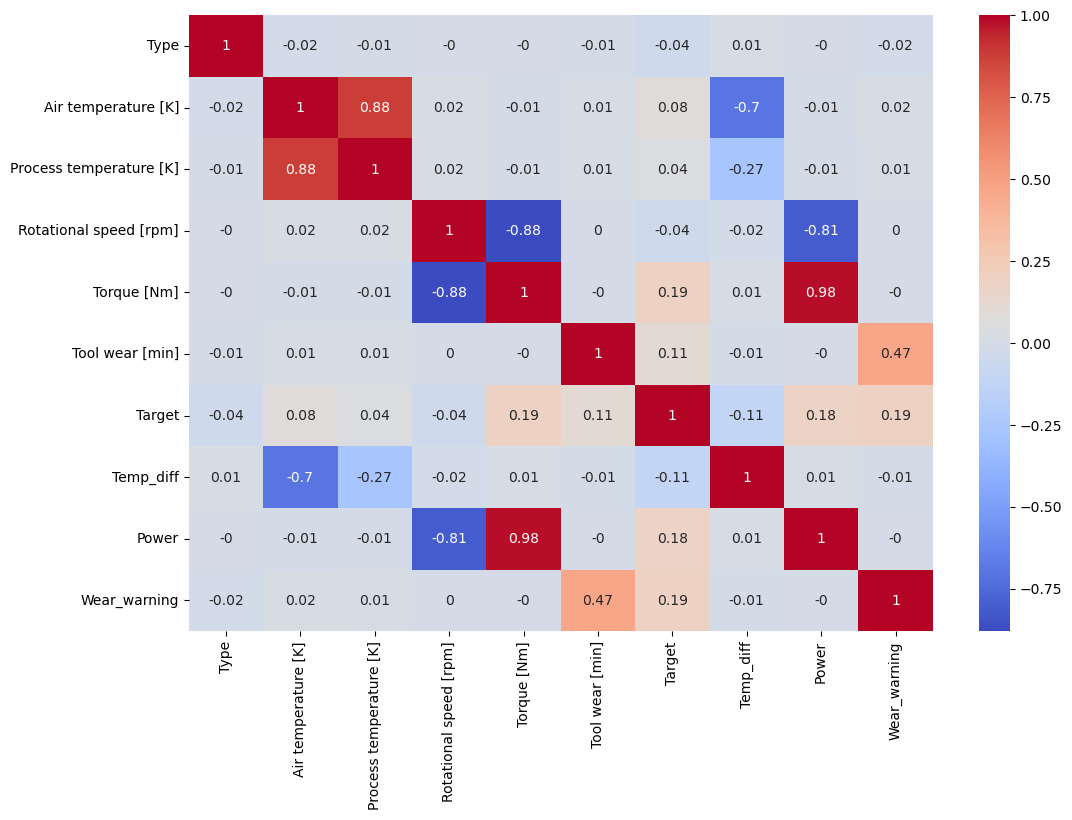

In [2]:
import matplotlib.pyplot as plt
import seaborn as sns

# Compute and plot correlation matrix
corr = df.corr(numeric_only=True).round(2)

plt.figure(figsize=(12, 8))
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.show()

## Feature Distribution vs. Target

Visualizing how specific features separate the normal operational state from failure events using boxplots combined with stripplots for data density.

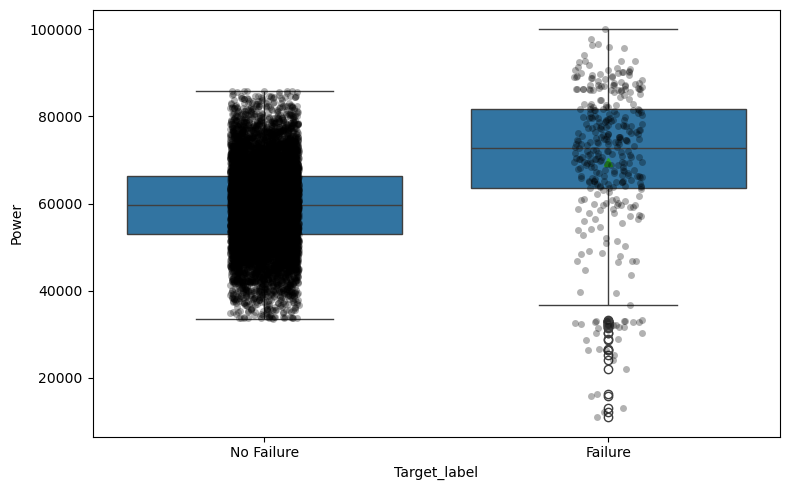

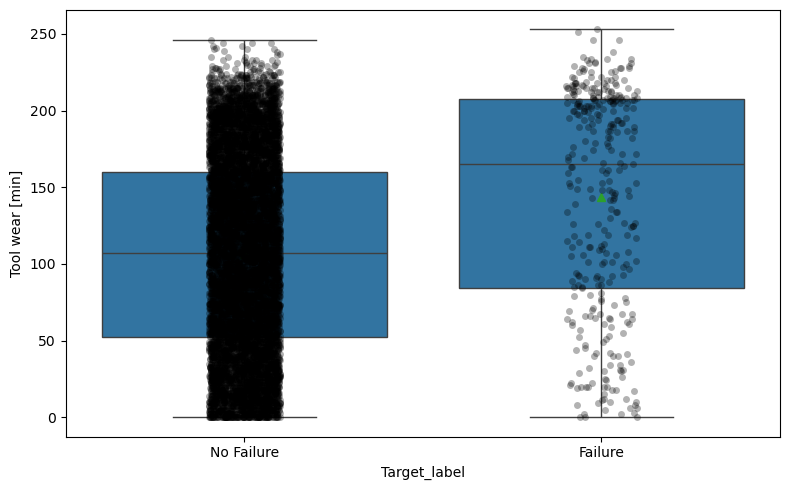

In [3]:
# Map target to strings strictly for visualization purposes
df['Target_label'] = df['Target'].map({0 : 'No Failure', 1 : 'Failure'})

# Power distribution plot
plt.figure(figsize=(8, 5))
sns.boxplot(x='Target_label', y='Power', data=df, showmeans=True)
sns.stripplot(x='Target_label', y='Power', data=df, color='black', alpha = 0.3)
plt.tight_layout()
plt.show()      

# Tool wear distribution plot
plt.figure(figsize=(8, 5))
sns.boxplot(x='Target_label', y='Tool wear [min]', data=df, showmeans=True)
sns.stripplot(x='Target_label', y='Tool wear [min]', data=df, color='black', alpha = 0.3)
plt.tight_layout()
plt.show()      

